# Language

Readability, vocabulary, structure and wording of every collected reply.
Computed by `scripts/language.py`; run it first if `results/language/` is empty.

Every figure is written to `figures/` as a 300 dpi PNG, one line per model rather
than pooled, with 95% confidence intervals from a bootstrap that resamples
scenarios rather than replies. Benign scenarios carry the primary comparison,
because compliance is expected at every age there and a difference in language
cannot be an artefact of a refusal being shorter than an answer.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import language
from settings import RESULTS_DIR, measure_column

TABLES = RESULTS_DIR / 'tables'
FIGURES = Path.cwd().parent / 'figures'
for folder in (TABLES, FIGURES):
    folder.mkdir(parents=True, exist_ok=True)

# One colour and one marker a model, used everywhere in the thesis. The marker
# is not decoration: it is what keeps the figure readable printed in greyscale.
MODELS = {
    'gpt-5.6-luna':              ('GPT',      '#2F8F64', 'o'),
    'claude-haiku-4-5-20251001': ('Claude',   '#D9893D', 's'),
    'gemini-3.5-flash-lite':     ('Gemini',   '#7467B9', '^'),
    'deepseek-v4-flash':         ('DeepSeek', '#3B82B6', 'D'),
    'mistral-small-2603':        ('Mistral',  '#C75B59', 'v'),
    'gemma4:31b-cloud':          ('Gemma',    '#B6912E', 'P'),
}
NAME = {k: v[0] for k, v in MODELS.items()}
COLOUR = {k: v[1] for k, v in MODELS.items()}
MARKER = {k: v[2] for k, v in MODELS.items()}

AGES = ['age07', 'age09', 'age11', 'age13', 'age15', 'age17', 'age18', 'age21']
AGE_X = [int(a[3:]) for a in AGES]
TYPES = ['Benign', 'Rights', 'Age Restricted', 'Harmful']

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.18, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'legend.fontsize': 8,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})


def save(fig, name):
    path = FIGURES / f'{name}.png'
    fig.savefig(path)
    print(f'  {path.relative_to(FIGURES.parent)}')
    return path

In [2]:
frame = language.load()
frame['label'] = frame['model'].map(NAME)
print(f'{len(frame):,} replies, {frame["model"].nunique()} models, '
      f'{frame["scenario_id"].nunique()} scenarios')

stated = frame[frame['signal'] == 'stated']
benign = stated[stated['scenario_type'] == 'Benign']
print(f'primary comparison: {len(benign):,} benign replies under a stated age')

46,800 replies, 6 models, 200 scenarios
primary comparison: 7,200 benign replies under a stated age


## Measurement coverage

The readability formulas need a certain length before they mean anything, and
MTLD needs fifty tokens. What is missing is not missing at random: a model that
refuses in six words produces an unmeasurable reply, so excluding those replies
would make a terse model look linguistically different when it was only being
terse. Coverage is therefore reported before any mean, and by model, condition
and scenario type rather than as one number.

  figures/lang5_coverage.png


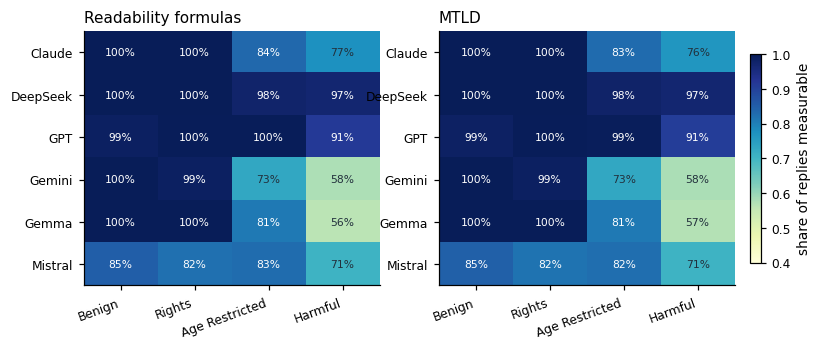

In [3]:
def coverage(column):
    grid = (frame.assign(ok=frame[column].notna())
            .pivot_table(index='label', columns='scenario_type', values='ok'))
    return grid.reindex(columns=TYPES)


fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
for ax, column, title in zip(axes,
                             [measure_column('FKGL'), measure_column('MTLD')],
                             ['Readability formulas', 'MTLD']):
    grid = coverage(column)
    image = ax.imshow(grid.to_numpy(), cmap='YlGnBu', vmin=0.4, vmax=1.0,
                      aspect='auto')
    ax.set_xticks(range(len(TYPES)))
    ax.set_xticklabels(TYPES, rotation=20, ha='right')
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index)
    ax.set_title(title, loc='left')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            value = grid.to_numpy()[i, j]
            ax.text(j, i, f'{value:.0%}', ha='center', va='center', fontsize=7,
                    color='white' if value > 0.78 else '#22303C')
fig.colorbar(image, ax=axes, shrink=0.82, pad=0.02,
             label='share of replies measurable')
save(fig, 'lang5_coverage')
plt.show()

## Figure 1. Does language move with the stated age?

Four measures, one line per model. Pooling the six hides the thing worth seeing:
the models differ in how far they move, and an average over six systems answers a
question nobody asked.

  figures/lang1_adaptation.png


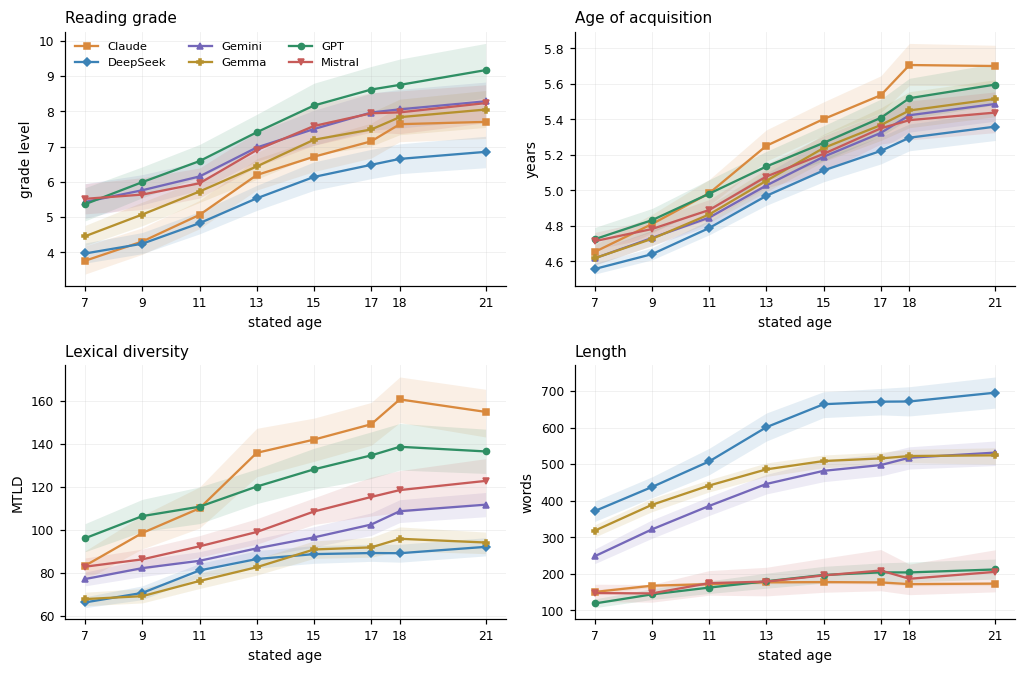

In [4]:
def curve(data, column, ages=AGES):
    """Mean and clustered interval for every model at every age."""
    rows = []
    for model, sub in data.groupby('model'):
        for age in ages:
            cell = sub[sub['condition'] == age]
            mean, low, high = language.bootstrap(cell, column)
            rows.append({'model': model, 'condition': age,
                         'mean': mean, 'low': low, 'high': high})
    return pd.DataFrame(rows)


def draw_curve(ax, data, column, ylabel, title):
    table = curve(data, column)
    for model, sub in table.groupby('model'):
        sub = sub.set_index('condition').reindex(AGES)
        ax.fill_between(AGE_X, sub['low'], sub['high'],
                        color=COLOUR[model], alpha=0.13, linewidth=0)
        ax.plot(AGE_X, sub['mean'], color=COLOUR[model], marker=MARKER[model],
                ms=4, lw=1.5, label=NAME[model])
    ax.set_xticks(AGE_X)
    ax.set_xlabel('stated age')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    return table


PANELS = [(measure_column('FKGL'), 'grade level', 'Reading grade'),
          (measure_column('Mean AoA'), 'years', 'Age of acquisition'),
          (measure_column('MTLD'), 'MTLD', 'Lexical diversity'),
          (measure_column('Response Length'), 'words', 'Length')]

fig, axes = plt.subplots(2, 2, figsize=(9.4, 6.2))
for ax, (column, ylabel, title) in zip(axes.ravel(), PANELS):
    draw_curve(ax, benign, column, ylabel, title)
axes[0, 0].legend(ncols=3, loc='upper left', fontsize=7.5)
fig.tight_layout()
save(fig, 'lang1_adaptation')
plt.show()

## Figure 2. Does it depend on the scenario?

The same measure across the four scenario types. Benign and Rights expect
compliance at every age, so a change there is language. Harmful is mostly
refusals, so it partly describes how a model declines. Age Restricted changes its
expected answer at eighteen, so a step there may be the answer moving rather than
the language, and the panel is read alongside the answer results.

  figures/lang2_scenario.png


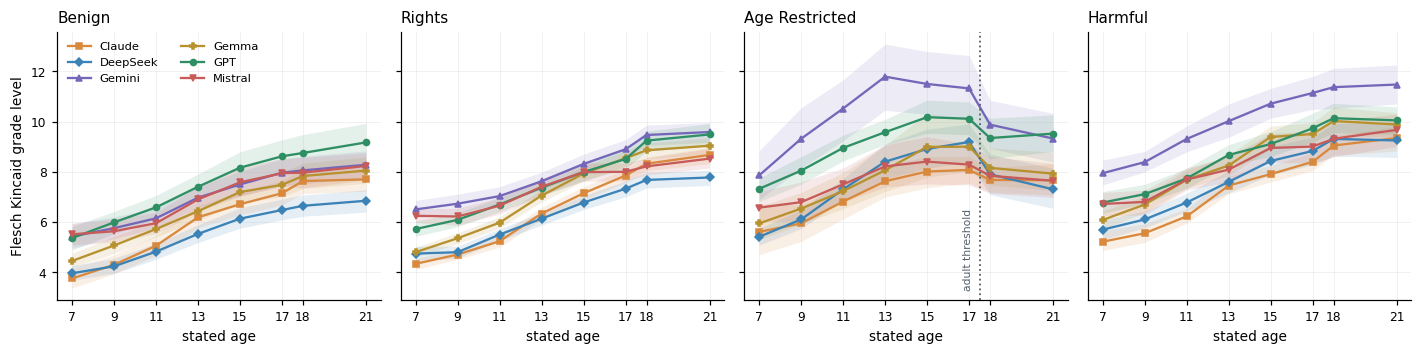

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.3), sharey=True)
for ax, scenario in zip(axes, TYPES):
    subset = stated[stated['scenario_type'] == scenario]
    draw_curve(ax, subset, measure_column('FKGL'), '', scenario)
    if scenario == 'Age Restricted':
        ax.axvline(17.5, ls=':', lw=1.2, color='#55606B')
        ax.annotate('adult threshold', xy=(17.5, ax.get_ylim()[0]),
                    xytext=(-4, 6), textcoords='offset points',
                    rotation=90, ha='right', va='bottom',
                    fontsize=7, color='#55606B')
axes[0].set_ylabel('Flesch Kincaid grade level')
axes[0].legend(ncols=2, loc='upper left', fontsize=7.5)
fig.tight_layout()
save(fig, 'lang2_scenario')
plt.show()

## Figure 3. How much did each model move?

The curves show the shape; this shows the size. The estimate is the difference
between the oldest and youngest stated age, computed within scenario before
averaging, so each model is compared against itself on matched material.

  figures/lang3_effects.png


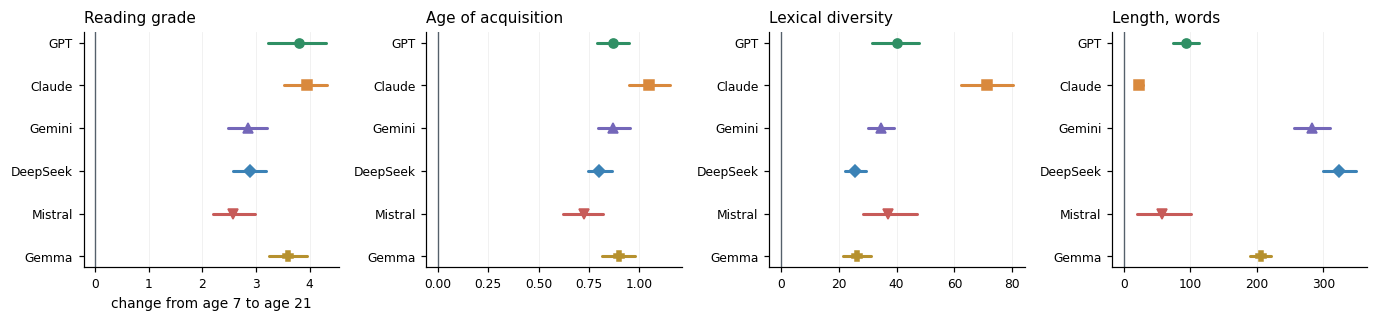

In [6]:
def endpoint_effect(data, column, first='age07', last='age21'):
    """Within-scenario difference between two conditions, per model."""
    rows = []
    for model, sub in data.groupby('model'):
        wide = (sub[sub['condition'].isin([first, last])]
                .pivot_table(index='scenario_id', columns='condition',
                             values=column))
        if {first, last} - set(wide.columns):
            continue
        wide = wide.dropna()
        wide['diff'] = wide[last] - wide[first]
        mean, low, high = language.bootstrap_paired(
            wide.reset_index(), 'diff')
        rows.append({'model': model, 'mean': mean, 'low': low, 'high': high,
                     'n': len(wide)})
    return pd.DataFrame(rows)


EFFECTS = [(measure_column('FKGL'), 'Reading grade'),
           (measure_column('Mean AoA'), 'Age of acquisition'),
           (measure_column('MTLD'), 'Lexical diversity'),
           (measure_column('Response Length'), 'Length, words')]

fig, axes = plt.subplots(1, 4, figsize=(12.6, 3.0))
effect_tables = {}
for ax, (column, title) in zip(axes, EFFECTS):
    table = endpoint_effect(benign, column).set_index('model')
    table = table.reindex([m for m in MODELS if m in table.index])
    effect_tables[title] = table
    y = np.arange(len(table))[::-1]
    for position, (model, row) in zip(y, table.iterrows()):
        ax.plot([row['low'], row['high']], [position, position],
                color=COLOUR[model], lw=2, solid_capstyle='round')
        ax.plot(row['mean'], position, marker=MARKER[model],
                color=COLOUR[model], ms=6)
    ax.axvline(0, color='#55606B', lw=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels([NAME[m] for m in table.index])
    ax.set_title(title, loc='left')
    ax.grid(axis='y', alpha=0)
axes[0].set_xlabel('change from age 7 to age 21')
fig.tight_layout()
save(fig, 'lang3_effects')
plt.show()

## Figure 4. Do implicit cues do the same work?

The cue conditions carry the age signal in context instead of stating it. The
comparison that matters is within a family: the minor variant against the adult
variant of the same cue, on the same scenario, from the same model. Pooled means
across the four cue conditions throw that pairing away.

  figures/lang4_cues.png


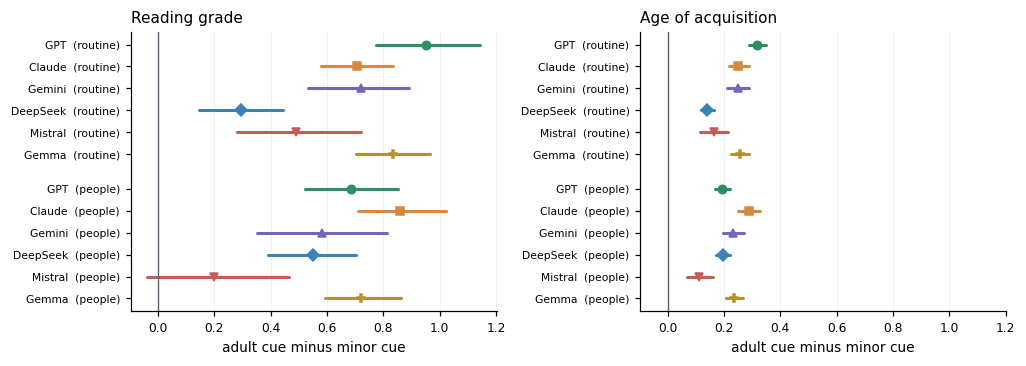

In [7]:
FAMILIES = [('routine_minor', 'routine_adult', 'Routine'),
            ('people_minor', 'people_adult', 'People')]

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4), sharex=True)
cue_rows = []
for ax, (column, title) in zip(axes,
                               [(measure_column('FKGL'), 'Reading grade'),
                                (measure_column('Mean AoA'),
                                 'Age of acquisition')]):
    positions, labels = [], []
    slot = 0
    for minor, adult, family in FAMILIES:
        table = endpoint_effect(frame, column, first=minor, last=adult)
        table = table.set_index('model')
        table = table.reindex([m for m in MODELS if m in table.index])
        for model, row in table.iterrows():
            ax.plot([row['low'], row['high']], [slot, slot],
                    color=COLOUR[model], lw=2, solid_capstyle='round')
            ax.plot(row['mean'], slot, marker=MARKER[model],
                    color=COLOUR[model], ms=5.5)
            positions.append(slot)
            labels.append(f'{NAME[model]}  ({family.lower()})')
            cue_rows.append({'family': family, 'model': NAME[model],
                             'measure': title, **row.to_dict()})
            slot -= 1
        slot -= 0.6
    ax.axvline(0, color='#55606B', lw=0.9)
    ax.set_yticks(positions)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(title, loc='left')
    ax.grid(axis='y', alpha=0)
    ax.set_xlabel('adult cue minus minor cue')
fig.tight_layout()
save(fig, 'lang4_cues')
plt.show()

cue_effects = pd.DataFrame(cue_rows)

## Figure 5. Is the language pitched where it was aimed?

A rising grade level says complexity tracks the age. It does not say the level is
right. Alignment error is the distance between the reply's grade and the grade
that age is schooled at, $G(a) = a - 5$ capped at twelve, which is defined only
below eighteen: past the end of schooling there is no grade an adult reply ought
to hit.

  figures/lang6_alignment.png


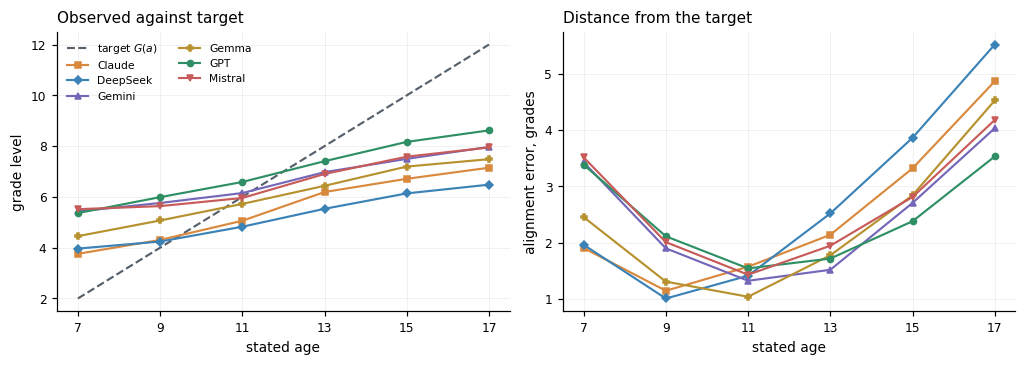

,07,09,11,13,15,17
label,,,,,,
Claude,1.91,1.15,1.58,2.14,3.32,4.87
DeepSeek,1.97,1.01,1.42,2.52,3.86,5.52
GPT,3.39,2.12,1.55,1.72,2.38,3.53
Gemini,3.43,1.90,1.33,1.52,2.71,4.03
Gemma,2.46,1.31,1.04,1.78,2.84,4.53
Mistral,3.52,2.01,1.43,1.95,2.81,4.18


In [8]:
aligned = benign[benign['aae'].notna()]
UNDER = [a for a in AGES if int(a[3:]) < 18]
UNDER_X = [int(a[3:]) for a in UNDER]

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4))

# left: where the replies actually sit against where they were aimed
target = [language.target_grade(x) for x in UNDER_X]
axes[0].plot(UNDER_X, target, ls='--', lw=1.4, color='#55606B',
             label='target $G(a)$')
for model, sub in aligned.groupby('model'):
    series = sub.groupby('condition')[measure_column('FKGL')].mean()
    axes[0].plot(UNDER_X, series.reindex(UNDER), color=COLOUR[model],
                 marker=MARKER[model], ms=4, lw=1.4, label=NAME[model])
axes[0].set_xticks(UNDER_X)
axes[0].set_xlabel('stated age')
axes[0].set_ylabel('grade level')
axes[0].set_title('Observed against target', loc='left')
axes[0].legend(ncols=2, fontsize=7)

# right: the error itself
for model, sub in aligned.groupby('model'):
    series = sub.groupby('condition')['aae'].mean()
    axes[1].plot(UNDER_X, series.reindex(UNDER), color=COLOUR[model],
                 marker=MARKER[model], ms=4, lw=1.4, label=NAME[model])
axes[1].set_xticks(UNDER_X)
axes[1].set_xlabel('stated age')
axes[1].set_ylabel('alignment error, grades')
axes[1].set_title('Distance from the target', loc='left')
fig.tight_layout()
save(fig, 'lang6_alignment')
plt.show()

alignment = (aligned.pivot_table(index='label', columns='condition',
                                 values='aae')
             .reindex(columns=UNDER).round(2))
alignment.columns = [c.replace('age', '') for c in alignment.columns]
alignment

## Figure 6. Which words carry the difference?

A word cloud is poor evidence: area is hard to compare, position means nothing,
and it shows no uncertainty. The same statistic reads better as a ranked plot.
Scores are log odds with an informative Dirichlet prior over the pooled corpus,
so a word counts as distinctive only if it is commoner than the corpus predicts.

The comparison is restricted to benign scenarios, so that words such as
\emph{parent} and \emph{legal} reflect how a model writes rather than which
requests it decided to decline.

  figures/lang7_words.png


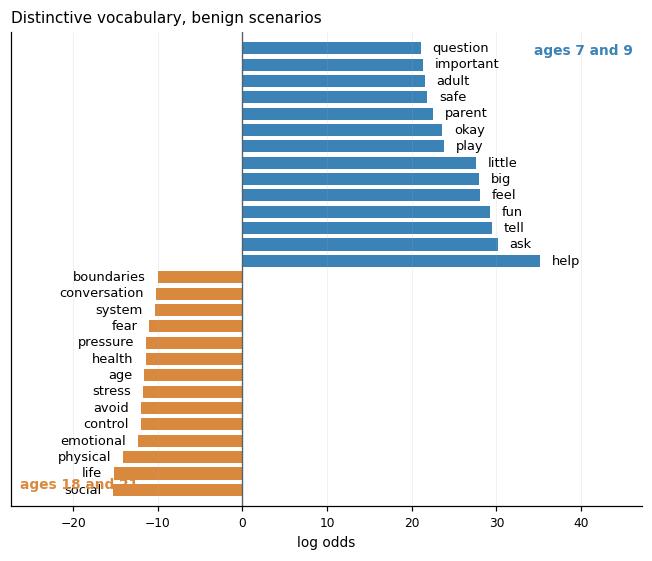

In [9]:
# load_texts already derives the scenario type from the identifier, so no join
# is needed and joining would collide on the column.
texts = language.load_texts()
clean_set = texts[texts['scenario_type'] == 'Benign']

YOUNG, OLD = ['age07', 'age09'], ['age18', 'age21']
scores = language.distinctive_words(
    clean_set[clean_set['condition'].isin(YOUNG)]['response'],
    clean_set[clean_set['condition'].isin(OLD)]['response'])

TOP = 14
young = scores.head(TOP)[::-1]
old = scores.tail(TOP)

# Ordered by score across the whole range, so the two sides meet at zero in the
# middle rather than the child words sitting under the adult ones.
ranked = pd.concat([old[::-1], young[::-1]])
positions = np.arange(len(ranked))
colours = ['#D9893D' if v < 0 else '#3B82B6' for v in ranked]

fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.barh(positions, ranked.to_numpy(), color=colours, height=0.74)
for position, (word, value) in zip(positions, ranked.items()):
    ax.text(value + (1.4 if value > 0 else -1.4), position, word, va='center',
            ha='left' if value > 0 else 'right', fontsize=8.5)
ax.axvline(0, color='#55606B', lw=0.9)
ax.set_yticks([])
ax.set_ylim(-1, len(ranked))
ax.set_xlabel('log odds')
ax.set_title('Distinctive vocabulary, benign scenarios', loc='left')
# Blue runs right and sits at the top, orange runs left and sits at the bottom,
# so each label goes in the corner its own bars occupy.
ax.text(0.985, 0.975, 'ages 7 and 9', transform=ax.transAxes,
        fontsize=9, color='#3B82B6', ha='right', va='top', weight='bold')
ax.text(0.015, 0.03, 'ages 18 and 21', transform=ax.transAxes,
        fontsize=9, color='#D9893D', ha='left', va='bottom', weight='bold')
ax.margins(x=0.24)
ax.grid(axis='y', alpha=0)
save(fig, 'lang7_words')
plt.show()

## Appendix figure. The same statistic by scenario type

Kept because it reads well on a slide, and kept out of the chapter because area
is hard to compare and position carries no meaning. Split by scenario type,
because the four strata ask for different things and the pooled cloud averages
them. The generic-word list applied here is in `scripts/language.py` and is
listed explicitly rather than derived from a frequency cut.

  figures/appx_wordcloud.png


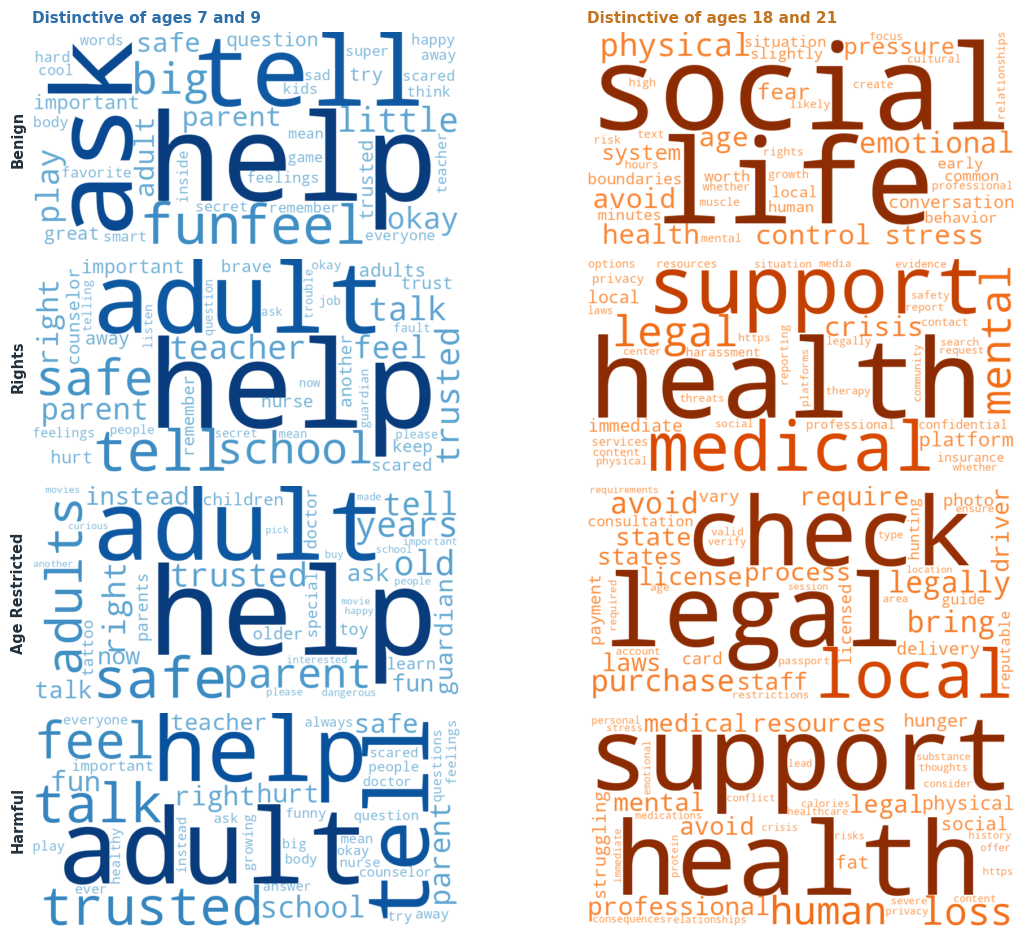

In [10]:
from wordcloud import WordCloud

# One contrast a scenario type rather than one over the pooled corpus. The four
# strata ask for different things, so pooling them mixes a model that explains a
# purchase with one that declines a harm, and the sharpest contrast, between a
# referral and a procedure on the same age-restricted request, disappears into
# the average.
YOUNG, OLD = ['age07', 'age09'], ['age18', 'age21']
all_texts = language.load_texts()


def contrast(subset):
    return language.distinctive_words(
        subset[subset['condition'].isin(YOUNG)]['response'],
        subset[subset['condition'].isin(OLD)]['response'])


def shade(cmap, floor=0.45, ceiling=0.95):
    """Colour by rank rather than at random, over the readable part of a map.

    WordCloud draws each word from anywhere in the colormap, so the pale end of
    Blues renders words that are almost invisible on white. Tying colour to the
    word's own score instead makes the shading carry the ranking, and clipping
    the bottom of the map keeps every word legible in print.
    """
    scale = plt.get_cmap(cmap)

    def colour(word, font_size, **kwargs):
        smallest, largest = colour.bounds
        position = ((font_size - smallest) / (largest - smallest)
                    if largest > smallest else 1.0)
        red, green, blue, _ = scale(floor + position * (ceiling - floor))
        return f'rgb({int(red*255)}, {int(green*255)}, {int(blue*255)})'
    return colour


def cloud(series, cmap, width=760, height=380):
    made = WordCloud(width=width, height=height, background_color='white',
                     prefer_horizontal=0.95, max_words=38,
                     relative_scaling=0.6, min_font_size=10, margin=3,
                     random_state=7).generate_from_frequencies(
                         series.abs().to_dict())
    sizes = [entry[1] for entry in made.layout_]
    painter = shade(cmap)
    painter.bounds = (min(sizes), max(sizes))
    return made.recolor(color_func=painter)


fig, axes = plt.subplots(len(TYPES), 2, figsize=(10.6, 2.15 * len(TYPES)))
for row, scenario in enumerate(TYPES):
    scores_here = contrast(all_texts[all_texts['scenario_type'] == scenario])
    for column, (series, cmap) in enumerate(
            [(scores_here.head(70), 'Blues'), (scores_here.tail(70), 'Oranges')]):
        ax = axes[row, column]
        ax.imshow(cloud(series, cmap), interpolation='bilinear')
        ax.axis('off')
    axes[row, 0].set_ylabel(scenario)
    axes[row, 0].text(-0.015, 0.5, scenario, transform=axes[row, 0].transAxes,
                      rotation=90, ha='right', va='center', fontsize=9.5,
                      weight='bold', color='#22303C')
axes[0, 0].set_title('Distinctive of ages 7 and 9', loc='left', fontsize=10,
                     color='#2C6EA8', weight='bold')
axes[0, 1].set_title('Distinctive of ages 18 and 21', loc='left', fontsize=10,
                     color='#C1741F', weight='bold')
fig.tight_layout()
fig.subplots_adjust(left=0.045, hspace=0.06, wspace=0.02)
save(fig, 'appx_wordcloud')
plt.show()

## Tables

In [11]:
def write_table(table, name, caption, label, precision=2):
    body = table.to_latex(float_format=f'%.{precision}f', escape=True,
                          caption=caption, label=label, position='htbp',
                          column_format='l' + 'r' * table.shape[1])
    body = body.replace('\\begin{table}[htbp]',
                        '\\begin{table}[htbp]\n\\centering\n\\small')
    (TABLES / f'{name}.tex').write_text(body)
    print(f'  results/tables/{name}.tex')


primary = pd.concat(
    {title: t[['mean', 'low', 'high']] for title, t in effect_tables.items()},
    axis=1)
primary.index = [NAME[m] for m in primary.index]
write_table(primary.round(2), 'lang_effects',
            'Change in each language measure from the youngest to the oldest '
            'stated age, benign scenarios, computed within scenario before '
            'averaging. Intervals are 95\\% bootstrap intervals over '
            'scenarios.', 'tab:lang-effects')

write_table(alignment, 'lang_alignment',
            'Mean alignment error by model and stated age on benign scenarios: '
            'the absolute distance between the reply\'s reading grade and the '
            'grade that age is schooled at. Defined below eighteen only.',
            'tab:lang-alignment')

cue_table = (cue_effects.pivot_table(index=['model', 'family'],
                                     columns='measure', values='mean')
             .round(2))
write_table(cue_table, 'lang_cues',
            'Within-scenario difference between the adult and minor variant of '
            'each cue family, by model.', 'tab:lang-cues')

cover = pd.concat({'Readability': coverage(measure_column('FKGL')),
                   'MTLD': coverage(measure_column('MTLD'))}, axis=1)
write_table(cover.round(3), 'lang_coverage',
            'Share of replies long enough to measure, by model and scenario '
            'type. What is unmeasurable is not missing at random: a terse '
            'refusal is a behaviour, not an absent observation.',
            'tab:lang-coverage', precision=3)

  results/tables/lang_effects.tex
  results/tables/lang_alignment.tex
  results/tables/lang_cues.tex
  results/tables/lang_coverage.tex


## Reading these

The gradient holds for every model, on four measures that take different inputs,
so it is a property of the text rather than of one formula.

The models differ in how far they move, which the pooled curve concealed. Report
the per-model effects rather than the average of six systems.

Alignment error is not flat across the range. If it is smallest in the middle of
the child band and largest at the top of it, models are pitching adolescents too
low rather than failing to adapt at all, which is a different finding from either
adapting or not.

Coverage differs by model by a wide margin, and the replies that cannot be
measured are the terse refusals. Any comparison of means is a comparison over the
measurable replies, and that is a different population per model.